In [1]:
from pyMuellerMat.physical_models.charis_physical_models import refractive_index
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# load in johnson refractive indices
import pandas as pd

johnson_data = pd.read_csv("Johnson.csv")
johnson_data
johnson_n = johnson_data.iloc[:49]
silver_n = johnson_n["n"].to_numpy().astype(float)
# convert wavelengths to floats and then numpy
wl = johnson_n["wl"].to_numpy().astype(float) * 1e-6 # convert from microns to meters
johnson_k = johnson_data.iloc[50:]
silver_k = johnson_k["n"].to_numpy().astype(float)


array([ 1.212,  1.232,  1.255,  1.277,  1.296,  1.312,  1.325,  1.336,
        1.342,  1.344,  1.357,  1.367,  1.378,  1.389,  1.393,  1.387,
        1.372,  1.331,  1.264,  1.161,  0.964,  0.616,  0.392,  0.829,
        1.142,  1.419,  1.657,  1.864,  2.07 ,  2.275,  2.462,  2.657,
        2.869,  3.093,  3.324,  3.586,  3.858,  4.152,  4.483,  4.838,
        5.242,  5.727,  6.312,  6.992,  7.795,  8.828, 10.1  , 11.85 ,
       14.08 ])

Text(0.5, 1.0, 'Real Refractive Index (n) Johnson Catalog Comparison')

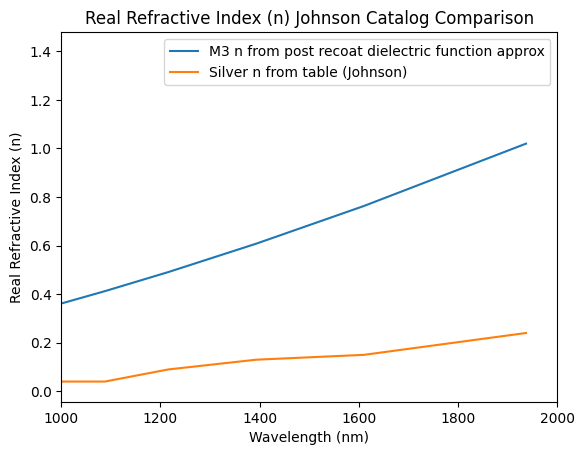

In [82]:
# load in dielectric function approx from paper
m1 = 1.768
b1 = 12.77
m2 = 2.455
b2 = 15.67

# dielectric function approx
def dielectric_func_approx_1(wavelength, m1=m1, b1=b1, m2=m2, b2=b2):
    er1 = (-10**b1) * (wavelength ** m1)
    return er1

def dielectric_func_approx_2(wavelength, m1=m1, b1=b1, m2=m2, b2=b2):
    er2 = (10**b2) * (wavelength ** m2)
    return er2

wavelengths = wl

er1s = dielectric_func_approx_1(wavelengths)
er2s = dielectric_func_approx_2(wavelengths)

refractive_indices = refractive_index(er1s,er2s)

# take real part of each entry for n 
n = np.real(refractive_indices)
# take im for k
k = np.imag(refractive_indices)

plt.plot(wavelengths*1e9, n, label="M3 n from post recoat dielectric function approx")
plt.plot(wavelengths*1e9, silver_n, label="Silver n from table (Johnson)")
plt.xlim(1000,2000)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Real Refractive Index (n)')
plt.legend()
plt.title('Real Refractive Index (n) Johnson Catalog Comparison')


Text(0.5, 1.0, 'Complex Refractive Index (k) Johnson Catalog Comparison')

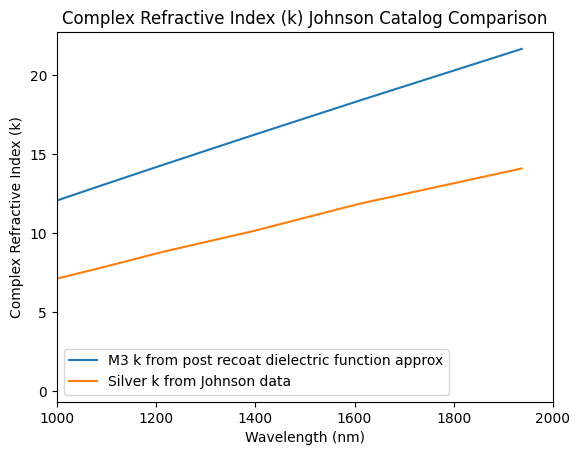

In [83]:
plt.plot(wavelengths*1e9, k, label="M3 k from post recoat dielectric function approx")
plt.plot(wavelengths*1e9, silver_k, label="Silver k from Johnson data")
plt.xlim(1000,2000)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Complex Refractive Index (k)')
plt.legend()
plt.title('Complex Refractive Index (k) Johnson Catalog Comparison')

In [62]:
import numpy as np

def compute_reflectivity(tilde_n, theta_deg, n1=1.0):
    """
    Calculates unpolarized power reflectivity array from complex refractive indices.

    Parameters
    ----------
    tilde_n : complex or np.ndarray
        Complex refractive index of the medium (n + 1j*k).
    theta_deg : float, optional
        Angle of incidence in degrees. Default is 0.0 (normal incidence).
    n1 : float or complex, optional
        Refractive index of the incident medium. Default is 1.0 (air/vacuum).

    Returns
    -------
    R_unpol : np.ndarray
        Array of unpolarized power reflectivity (values between 0.0 and 1.0).
    """
    theta_i = np.radians(theta_deg)
    
    # Snell's law for complex media
    sin_theta_t = (n1 / tilde_n) * np.sin(theta_i)
    cos_theta_t = np.sqrt(1.0 - sin_theta_t**2 + 0j)
    cos_theta_i = np.cos(theta_i)
    
    # Fresnel amplitude reflection coefficients
    r_s = (n1 * cos_theta_i - tilde_n * cos_theta_t) / (n1 * cos_theta_i + tilde_n * cos_theta_t)
    r_p = (tilde_n * cos_theta_i - n1 * cos_theta_t) / (tilde_n * cos_theta_i + n1 * cos_theta_t)
    
    # Power reflectivity R = |r|^2
    R_s = np.abs(r_s)**2
    R_p = np.abs(r_p)**2
    
    return 0.5 * (R_s + R_p)

Text(0.5, 1.0, 'Replicating Subaru Reflectvity Plot via Fresnel Eqns')

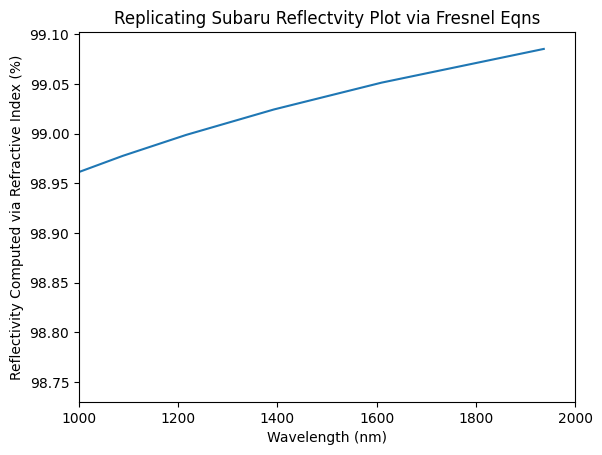

In [85]:
ref = compute_reflectivity(n+k*1j, 45)
plt.plot(wl*1e9,ref*100)
plt.xlabel('Wavelength (nm)')
plt.xlim(1000,2000)
plt.ylabel('Reflectivity Computed via Refractive Index (%)')
plt.title('Replicating Subaru Reflectvity Plot via Fresnel Eqns')